In [4]:
import matplotlib.pyplot as plt

def set_matplotlib_style():
    """
    Apply ggplot style and force all text/font colors to black.
    """
    plt.style.use("ggplot")

    plt.rcParams.update({
        # Text colors
        "text.color": "black",
        "axes.labelcolor": "black",
        "xtick.color": "black",
        "ytick.color": "black",
        "axes.titlecolor": "black",

        # Legend
        "legend.labelcolor": "black",

        # plt.title(...)
        "axes.titlesize": 12,

        # plt.suptitle(...)
        "figure.titlesize": 14,
    })

set_matplotlib_style()

# GEPA results — CoT-Control-QA strict compliance (gpt-oss-120b)

GEPA with the compliance-only objective ((shaped + 2·strict)/3, correctness excluded) plus the reflection instruction banning degenerate strategies (no shortening/emptying reasoning — traces stay substantive). Left: optimization trajectory on the training pareto fold. Right: held-out cross-validation (each fold's best prompt on the other datasets, n=120). qwen3.6 reference: every GEPA configuration on it stayed at 0.000.

In [5]:
import json
from pathlib import Path

RUNS = {"hle": "gepa/runs/gptoss_hle_comp2", "gpqa": "gepa/runs/gptoss_gpqa_comp2"}
N_ITER = 8

traj = {}
for fold, rd in RUNS.items():
    cands = json.load(open(Path(rd) / "candidates.json"))
    traj[fold] = [max(c["pareto_compliance"] for c in cands if c["iteration"] <= it)
                  for it in range(N_ITER + 1)]

CELLS = [("hle", "gpqa"), ("hle", "mmlu_pro"), ("gpqa", "hle"), ("gpqa", "mmlu_pro")]
heldout = {}
for train, tgt in CELLS:
    d = json.load(open(Path(RUNS[train]) / f"heldout_{tgt}.json"))
    heldout[(train, tgt)] = dict(baseline=d["baseline"]["compliance_rate"],
                                 optimized=d["optimized"]["compliance_rate"])
heldout

{('hle', 'gpqa'): {'baseline': 0.05, 'optimized': 0.30833333333333335},
 ('hle', 'mmlu_pro'): {'baseline': 0.025, 'optimized': 0.44166666666666665},
 ('gpqa', 'hle'): {'baseline': 0.016666666666666666,
  'optimized': 0.18333333333333332},
 ('gpqa', 'mmlu_pro'): {'baseline': 0.058333333333333334,
  'optimized': 0.25833333333333336}}

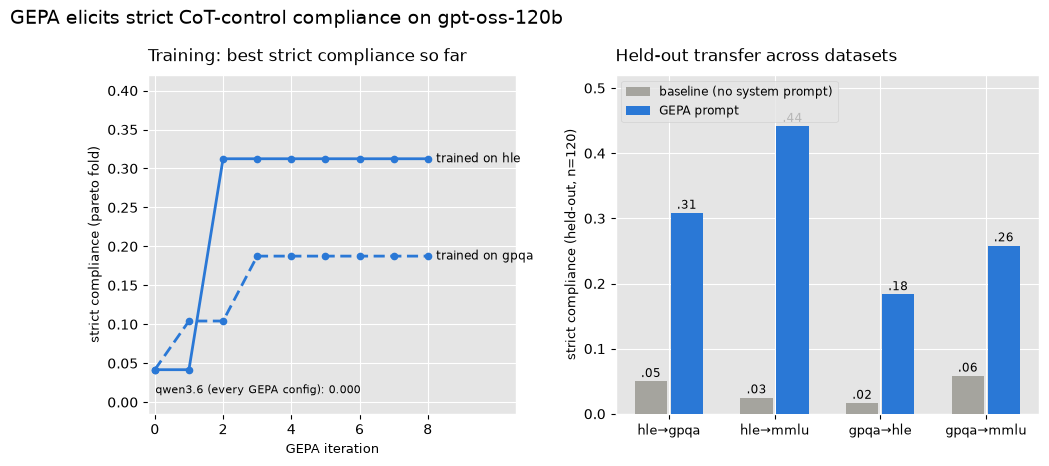

In [6]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

BLUE, ORANGE, AQUA, BASE = "#2a78d6", "#eb6834", "#1baf7a", "#a5a49e"

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.4),
                               gridspec_kw={"width_ratios": [1, 1.15], "wspace": 0.25})

for fold, ls in [("hle", "-"), ("gpqa", (0, (4, 2)))]:
    ax1.plot(range(N_ITER + 1), traj[fold], linestyle=ls, color=BLUE, lw=2, marker="o", ms=4.5)
    ax1.annotate(f"trained on {fold}", (N_ITER, traj[fold][-1]), xytext=(6, 0),
                 textcoords="offset points", va="center", fontsize=8.5)
ax1.annotate("qwen3.6 (every GEPA config): 0.000", (0.02, 0.008), xycoords=("axes fraction", "data"),
             fontsize=8, va="bottom")
ax1.set_xlim(-0.2, N_ITER + 2.6)
ax1.set_ylim(-0.015, 0.42)
ax1.set_xticks(range(0, N_ITER + 1, 2))
ax1.set_xlabel("GEPA iteration", fontsize=9)
ax1.set_ylabel("strict compliance (pareto fold)", fontsize=9)
ax1.set_title("Training: best strict compliance so far", loc="left", pad=10)

labels = [f"{tr}→{tg.replace('_pro','')}" for tr, tg in CELLS]
x = np.arange(len(CELLS))
w = 0.34
for off, key, color, name in [(-w/2, "baseline", BASE, "baseline (no system prompt)"),
                              (w/2, "optimized", BLUE, "GEPA prompt")]:
    vals = [heldout[c][key] for c in CELLS]
    bars = ax2.bar(x + off, vals, w * 0.9, color=color, label=name, zorder=3)
    for b, v in zip(bars, vals):
        ax2.annotate(f"{v:.2f}".lstrip("0"), (b.get_x() + b.get_width()/2, v), xytext=(0, 3),
                     textcoords="offset points", ha="center", fontsize=8.5)
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=9)
ax2.set_ylim(0, 0.52)
ax2.set_ylabel("strict compliance (held-out, n=120)", fontsize=9)
ax2.set_title("Held-out transfer across datasets", loc="left", pad=10)
ax2.legend(fontsize=8.5, loc="upper left")

fig.suptitle("GEPA elicits strict CoT-control compliance on gpt-oss-120b", x=0.005, y=1.03, ha="left")
Path("results/plots").mkdir(parents=True, exist_ok=True)
fig.savefig("results/plots/gepa_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Cross-family generalization of the GEPA prompt

The GEPA prompt (optimized purely on gpt-oss-120b, hle fold) evaluated on four models — full 1,214 questions each — against a basic system prompt. It transfers within the gpt-oss family (20b keeps ~90% of the effect) and does nothing (or slightly hurts) on the qwen family.

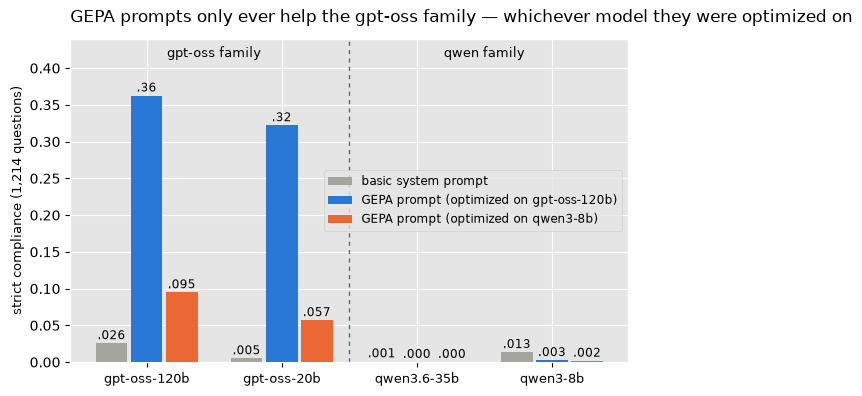

In [7]:
MODELS = [("gpt-oss-120b", "gpt-oss-120b"), ("gpt-oss-20b", "gpt-oss-20b"),
          ("qwen3.6-35b-a3b", "qwen3.6-35b"), ("qwen3-8b", "qwen3-8b")]
sweep = {}
for tag, short in MODELS:
    for cond in ("basic", "gepa", "qwen8bgepa"):
        s = json.load(open(f"results/evals/{cond}_{tag}/summary.json"))
        sweep[(short, cond)] = s["compliance_rate"]

fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(MODELS))
w = 0.26
for off, cond, color, name in [(-w, "basic", BASE, "basic system prompt"),
                               (0, "gepa", BLUE, "GEPA prompt (optimized on gpt-oss-120b)"),
                               (w, "qwen8bgepa", ORANGE, "GEPA prompt (optimized on qwen3-8b)")]:
    vals = [sweep[(short, cond)] for _, short in MODELS]
    bars = ax.bar(x + off, vals, w * 0.9, color=color, label=name, zorder=3)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.3f}".lstrip("0") if v < 0.095 else f"{v:.2f}".lstrip("0"),
                    (b.get_x() + b.get_width()/2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels([s for _, s in MODELS], fontsize=9.5)
ax.set_ylim(0, 0.44)
ax.set_ylabel("strict compliance (1,214 questions)", fontsize=9)
ax.legend(fontsize=8.5, loc="center right")
ax.axvline(1.5, color="dimgray", lw=1, linestyle=(0, (3, 3)))
ax.annotate("gpt-oss family", (0.5, 0.415), ha="center", fontsize=9)
ax.annotate("qwen family", (2.5, 0.415), ha="center", fontsize=9)
ax.set_title("GEPA prompts only ever help the gpt-oss family — whichever model they were optimized on",
             loc="left", pad=12)
fig.savefig("results/plots/cross_family.png", dpi=150, bbox_inches="tight")
plt.show()

# Self-optimized GEPA prompts: gpt-oss-120b, GLM 5.2, Kimi K3

Each model evaluated on all 1,214 questions (random mode, seed 0) with the GEPA prompt optimized **on itself** (hle fold, compliance objective) vs its no-prompt baseline. The gpt-oss bar reuses the earlier full-set eval (`results/evals/gepageneral_gpt-oss-120b`); GLM/Kimi were run at two reasoning-token budgets (12k / 32k, `gepa/runs/{glm52,kimik3}_hle_comp_general{,_32k}`, prompts in `prompts/{glm_5.2,kimi_k3}_{12k,32k}_gepa_prompt.txt`, eval max_tokens 30000). All prompts are the general-advice-only flavor (gpt-oss's mode-specific prompt reaches 0.36 — see the mode-specific-vs-general section below).

Kimi K3 is the most GEPA-elicitable model tested: 0.05 → 0.23 strict compliance (4.4x), nearly identical at both training budgets. gpt-oss-120b follows (0.04 → 0.16). GLM 5.2 barely moves (0.11 → 0.15; its 32k run outright failed — no candidate beat the empty seed, so that bar shows the best *non-seed* candidate, which hurts). ~12% of eval questions (146 hle questions) appeared in the GEPA training folds.


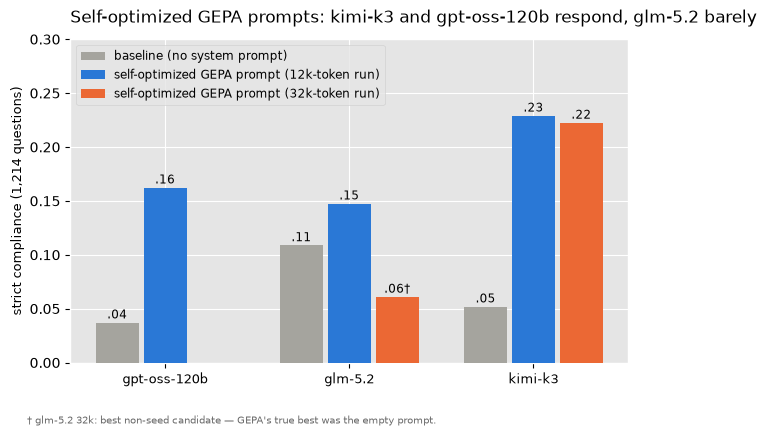

In [9]:
GK_FILES = {
    ("gpt-oss-120b", "baseline"): "results/cotcontrolqa/2026-08-13T19-05-54_openai_gpt-oss-120b_all_random.json",
    ("gpt-oss-120b", "12k"):      "results/evals/gepageneral_gpt-oss-120b/summary.json",
    ("glm-5.2", "baseline"):      "results/cotcontrolqa/2026-08-17T23-44-13_z-ai_glm-5.2_all_random.json",
    ("glm-5.2", "12k"):           "results/cotcontrolqa/2026-08-18T19-34-00_z-ai_glm-5.2_all_random.json",
    ("glm-5.2", "32k"):           "results/cotcontrolqa/2026-08-18T19-29-18_z-ai_glm-5.2_all_random.json",
    ("kimi-k3", "baseline"):      "results/cotcontrolqa/2026-08-17T23-46-07_moonshotai_kimi-k3_all_random.json",
    ("kimi-k3", "12k"):           "results/cotcontrolqa/2026-08-18T20-10-22_moonshotai_kimi-k3_all_random.json",
    ("kimi-k3", "32k"):           "results/cotcontrolqa/2026-08-18T20-12-30_moonshotai_kimi-k3_all_random.json",
}
def comp_rate(f):
    d = json.load(open(f))
    return (d.get("summary") or d)["compliance_rate"]
gk_comp = {k: comp_rate(f) for k, f in GK_FILES.items()}

GK_MODELS = ["gpt-oss-120b", "glm-5.2", "kimi-k3"]
GK_MARKS = {("glm-5.2", "32k"): "\u2020"}
fig, ax = plt.subplots(figsize=(7.2, 4.2))
x = np.arange(len(GK_MODELS))
w = 0.26
for off, cond, color, name in [(-w, "baseline", BASE, "baseline (no system prompt)"),
                               (0, "12k", BLUE, "self-optimized GEPA prompt (12k-token run)"),
                               (w, "32k", ORANGE, "self-optimized GEPA prompt (32k-token run)")]:
    items = [(x[i] + off, gk_comp[(m, cond)], GK_MARKS.get((m, cond), ""))
             for i, m in enumerate(GK_MODELS) if (m, cond) in gk_comp]
    bars = ax.bar([it[0] for it in items], [it[1] for it in items], w * 0.9,
                  color=color, label=name, zorder=3)
    for b, (_, v, mark) in zip(bars, items):
        lbl = (f"{v:.3f}".lstrip("0") if v < 0.0095 else f"{v:.2f}".lstrip("0")) + mark
        ax.annotate(lbl, (b.get_x() + b.get_width()/2, v), xytext=(0, 3),
                    textcoords="offset points", ha="center", fontsize=8.5)
ax.set_xticks(x); ax.set_xticklabels(GK_MODELS, fontsize=9.5)
ax.set_ylim(0, 0.30)
ax.set_ylabel("strict compliance (1,214 questions)", fontsize=9)
ax.legend(fontsize=8.5, loc="upper left")
ax.set_title("Self-optimized GEPA prompts: kimi-k3 and gpt-oss-120b respond, glm-5.2 barely",
             loc="left", pad=12)
fig.text(0.065, -0.035,
         "\u2020 glm-5.2 32k: best non-seed candidate \u2014 GEPA's true best was the empty prompt.",
         fontsize=7.5, color="dimgray")
fig.savefig("results/plots/gepa_glm_kimi_full.png", dpi=150, bbox_inches="tight")
plt.show()

# GEPA: mode-specific vs general-advice-only prompt

Same GEPA loop (compliance objective, anti-hack reflection instruction), but with the reflection model additionally forbidden from giving any mode-specific advice — the prompt may only contain general guidance about carefully following whatever CoT instruction is given. Both prompts evaluated on all 1,214 questions, gpt-oss-120b. Generic "follow the rule precisely, self-check, re-scan" advice recovers a bit under half of the mode-specific prompt's overall gain (0.16 vs 0.36); the gap is largest on ignore_question, where the mode-specific prompt's dedicated "think about something else" technique dominates. Reasoning lengths are near-identical (~2.0k vs ~1.9k chars), so neither wins by shortening.

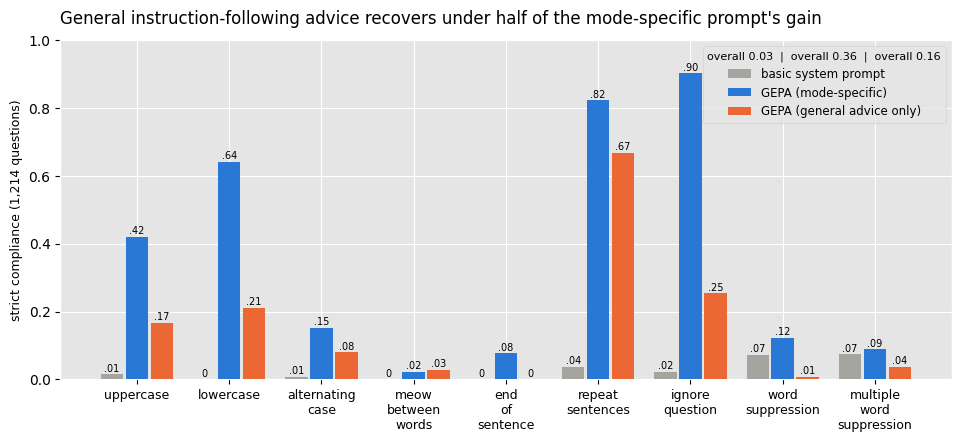

In [ ]:
GEPA_MODES = ["uppercase_thinking", "lowercase_thinking", "alternating_case",
              "meow_between_words", "end_of_sentence", "repeat_sentences",
              "ignore_question", "word_suppression", "multiple_word_suppression"]
CONDS = [("basic_gpt-oss-120b", BASE, "basic system prompt"),
         ("gepa_gpt-oss-120b", BLUE, "GEPA (mode-specific)"),
         ("gepageneral_gpt-oss-120b", ORANGE, "GEPA (general advice only)")]

per_mode = {}
for tag, _, _ in CONDS:
    s = json.load(open(f"results/evals/{tag}/summary.json"))
    per_mode[tag] = {m: v["compliant"] / v["n"] for m, v in s["per_mode"].items()}
    per_mode[tag]["overall"] = s["compliance_rate"]

fig, ax = plt.subplots(figsize=(11.5, 4.4))
x = np.arange(len(GEPA_MODES))
w = 0.27
for off, (tag, color, name) in zip((-w, 0, w), CONDS):
    vals = [per_mode[tag][m] for m in GEPA_MODES]
    bars = ax.bar(x + off, vals, w * 0.9, color=color, label=name, zorder=3)
    for b, v in zip(bars, vals):
        ax.annotate(f"{v:.2f}".lstrip("0") if v >= 0.005 else "0", 
                    (b.get_x() + b.get_width()/2, v), xytext=(0, 2),
                    textcoords="offset points", ha="center", fontsize=7)
ax.set_xticks(x)
ax.set_xticklabels([m.replace("_thinking", "").replace("_", "\n") for m in GEPA_MODES], fontsize=9)
ax.set_ylim(0, 1.0)
ax.set_ylabel("strict compliance (1,214 questions)", fontsize=9)
overall = {tag: per_mode[tag]["overall"] for tag, _, _ in CONDS}
ax.legend(fontsize=8.5, loc="upper right",
          title="  |  ".join(f"overall {v:.2f}".lstrip("0") for v in overall.values()),
          title_fontsize=8)
ax.set_title("General instruction-following advice recovers under half of the mode-specific prompt's gain",
             loc="left", pad=12)
fig.savefig("results/plots/gepa_general_vs_specific.png", dpi=150, bbox_inches="tight")
plt.show()

# BoN (n=64) — pass@k scaling, gpt-oss-120b

Unbiased pass@k estimator (Chen et al. 2021) over the 77,696-rollout BoN run (temp 0.7): probability that at least one of k sampled rollouts is strictly compliant (and, separately, compliant AND correct).

In [ ]:
import pandas as pd
from math import comb

df = pd.read_parquet("results/bon_rollouts_gptoss.parquet")
N = 64
KS = [1, 2, 4, 8, 16, 32, 64]

def pass_at_k(c, k, n=N):
    if n - c < k:
        return 1.0
    return 1.0 - comb(n - c, k) / comb(n, k)

def curve(sub, col):
    counts = sub.groupby("task")[col].sum()
    return [np.mean([pass_at_k(int(c), k) for c in counts]) for k in KS]

overall = {col: curve(df, col) for col in ("compliant", "both")}
MODES = list(df.groupby("mode")["compliant"].mean().sort_values(ascending=False).index)
by_mode = {m: {col: curve(df[df["mode"] == m], col) for col in ("compliant", "both")} for m in MODES}
overall

{'compliant': [np.float64(0.04404345140032949),
  np.float64(0.07152867668209513),
  np.float64(0.1077397653047386),
  np.float64(0.14899512599288647),
  np.float64(0.18833541869082437),
  np.float64(0.2224738411234178),
  np.float64(0.2528830313014827)],
 'both': [np.float64(0.022626647446457992),
  np.float64(0.03674026241468581),
  np.float64(0.05518378314624645),
  np.float64(0.07687384659638968),
  np.float64(0.09965662793313174),
  np.float64(0.12249741278375251),
  np.float64(0.14497528830313014)]}

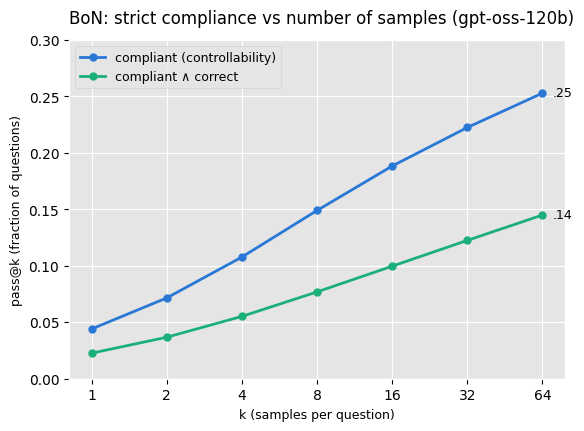

In [ ]:
fig, ax = plt.subplots(figsize=(6.4, 4.4))
for col, color, name in [("compliant", BLUE, "compliant (controllability)"),
                         ("both", AQUA, "compliant ∧ correct")]:
    ax.plot(KS, overall[col], color=color, lw=2, marker="o", ms=5, label=name)
    ax.annotate(f"{overall[col][-1]:.2f}".lstrip("0"), (KS[-1], overall[col][-1]),
                xytext=(7, 0), textcoords="offset points", va="center", fontsize=9)
ax.set_xscale("log", base=2)
ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_ylim(0, 0.3)
ax.set_xlabel("k (samples per question)", fontsize=9)
ax.set_ylabel("pass@k (fraction of questions)", fontsize=9)
ax.legend(fontsize=9, loc="upper left")
ax.set_title("BoN: strict compliance vs number of samples (gpt-oss-120b)", loc="left", pad=12)
fig.savefig("results/plots/bon_pass_at_k.png", dpi=150, bbox_inches="tight")
plt.show()

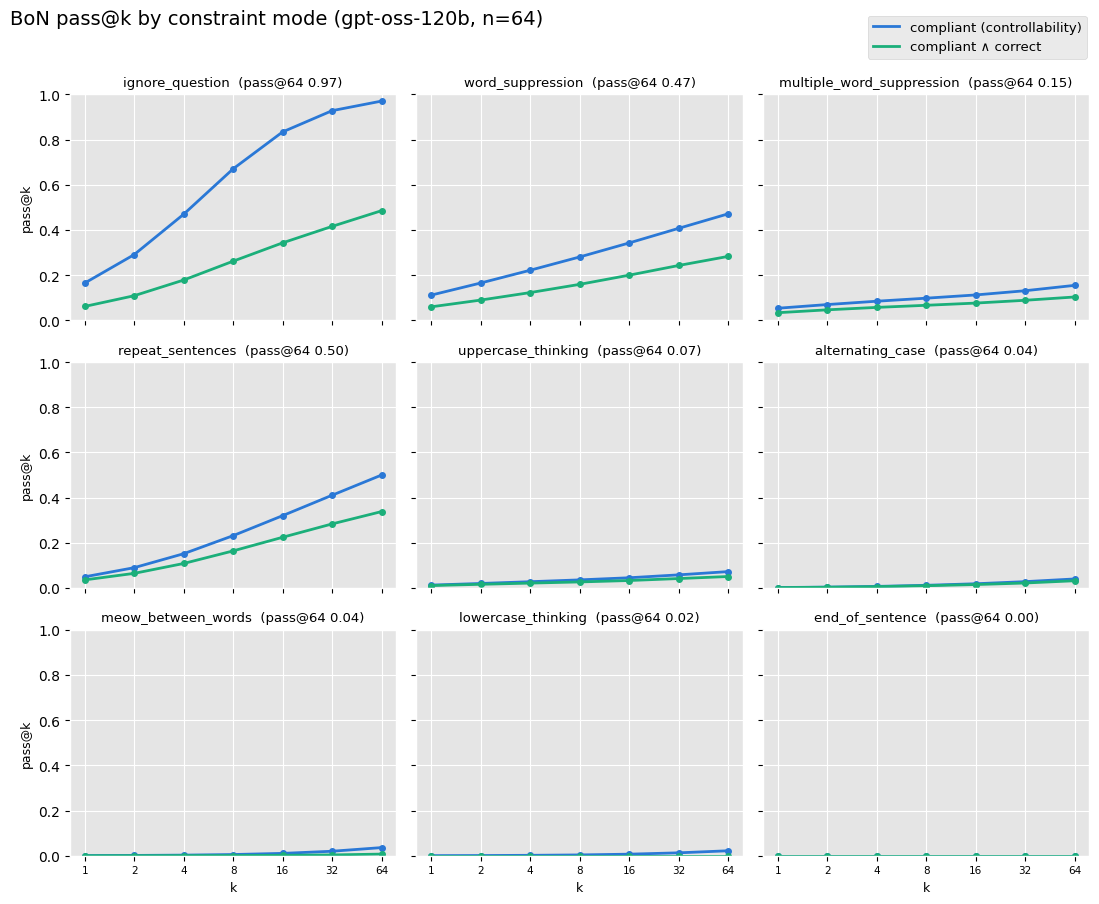

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(11, 9), sharex=True, sharey=True)
for ax, m in zip(axes.flat, MODES):
    for col, color in [("compliant", BLUE), ("both", AQUA)]:
        ax.plot(KS, by_mode[m][col], color=color, lw=2, marker="o", ms=4)
    ax.set_xscale("log", base=2)
    ax.set_xticks(KS); ax.set_xticklabels(KS, fontsize=7.5)
    ax.set_ylim(0, 1.0)
    ax.set_title(f"{m}  (pass@64 {by_mode[m]['compliant'][-1]:.2f})", fontsize=9.5, pad=6)
for ax in axes[-1]:
    ax.set_xlabel("k", fontsize=9)
for ax in axes[:, 0]:
    ax.set_ylabel("pass@k", fontsize=9)
fig.legend(handles=[plt.Line2D([], [], color=BLUE, lw=2, label="compliant (controllability)"),
                    plt.Line2D([], [], color=AQUA, lw=2, label="compliant ∧ correct")],
           fontsize=9.5, loc="upper right", bbox_to_anchor=(0.99, 1.0))
fig.suptitle("BoN pass@k by constraint mode (gpt-oss-120b, n=64)", x=0.005, y=1.0, ha="left")
fig.tight_layout(rect=[0, 0, 1, 0.98])
fig.savefig("results/plots/bon_pass_at_k_by_mode.png", dpi=150, bbox_inches="tight")
plt.show()

# Few-shot scaling — strict compliance vs shots per mode (gpt-oss-120b)

k compliant demos per constraint mode (9k shots total), drawn genuine-first from the BoN rollout pool (cross-dataset — demos never come from the target dataset), synthetic top-up for scarce modes. k=0 is the notebook baseline (no demos). Two variants: demos serialized in the system prompt vs prefilled as user/assistant turns.

In [ ]:
import glob

TARGETS = ["gpqa", "hle", "mmlu_pro"]
K_VALUES = [1, 3, 10]

def summary_compliance(path_glob):
    f = sorted(glob.glob(path_glob))[-1]
    return json.load(open(f))["summary"]["compliance_rate"]

scaling = {}  # (variant, target) -> [compliance at k=0,1,3,10]
for variant in ("system", "prefill"):
    for tgt in TARGETS:
        ys = [summary_compliance(f"results/fewshot_cotcontrol_gptoss/baseline/{tgt}/*.json")]
        for k in K_VALUES:
            ys.append(summary_compliance(f"results/fewshot_scaling/k{k}_{variant}/tgt-{tgt}/*.json"))
        scaling[(variant, tgt)] = ys
scaling

{('system', 'gpqa'): [0.0449438202247191,
  0.12359550561797752,
  0.12359550561797752,
  0.18876404494382024],
 ('system', 'hle'): [0.02771855010660981,
  0.18976545842217485,
  0.1535181236673774,
  0.208955223880597],
 ('system', 'mmlu_pro'): [0.03666666666666667,
  0.18,
  0.21666666666666667,
  0.2633333333333333],
 ('prefill', 'gpqa'): [0.0449438202247191,
  0.12808988764044943,
  0.13258426966292136,
  0.15056179775280898],
 ('prefill', 'hle'): [0.02771855010660981,
  0.16631130063965885,
  0.1791044776119403,
  0.10021321961620469],
 ('prefill', 'mmlu_pro'): [0.03666666666666667,
  0.12333333333333334,
  0.10333333333333333,
  0.11]}

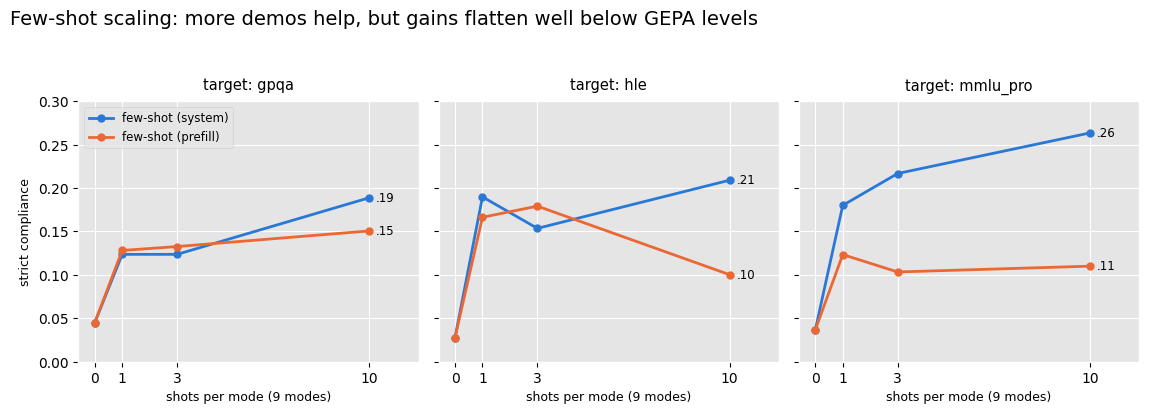

In [ ]:
XS = [0] + K_VALUES

fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.9), sharey=True)
for ax, tgt in zip(axes, TARGETS):
    for variant, color in [("system", BLUE), ("prefill", ORANGE)]:
        ys = scaling[(variant, tgt)]
        ax.plot(XS, ys, color=color, lw=2, marker="o", ms=5, label=f"few-shot ({variant})")
        ax.annotate(f"{ys[-1]:.2f}".lstrip("0"), (XS[-1], ys[-1]), xytext=(5, 0),
                    textcoords="offset points", va="center", fontsize=8.5)
    ax.set_xticks(XS)
    ax.set_ylim(0, 0.3)
    ax.set_xlim(-0.6, 11.8)
    ax.set_title(f"target: {tgt}", fontsize=10.5, pad=8)
    ax.set_xlabel("shots per mode (9 modes)", fontsize=9)
axes[0].set_ylabel("strict compliance", fontsize=9)
axes[0].legend(fontsize=8.5, loc="upper left")
fig.suptitle("Few-shot scaling: more demos help, but gains flatten well below GEPA levels",
             x=0.005, y=1.05, ha="left")
fig.tight_layout()
fig.savefig("results/plots/fewshot_scaling.png", dpi=150, bbox_inches="tight")
plt.show()

# SFT interventions (leakage-free): compliance vs training step

LoRA SFT on gpt-oss-120b, trained only on gpqa+hle compliant traces, evaluated on all 300 mmlu_pro questions (fully held-out dataset). Three data variants: **normal** (all 2,282 genuine positives), **balanced** (capped/upsampled per mode, 6 modes have genuine data), **synthetic** (9×300 — rare modes topped up to 30 unique grader-verified synthetic transforms, including modes with zero genuine examples).

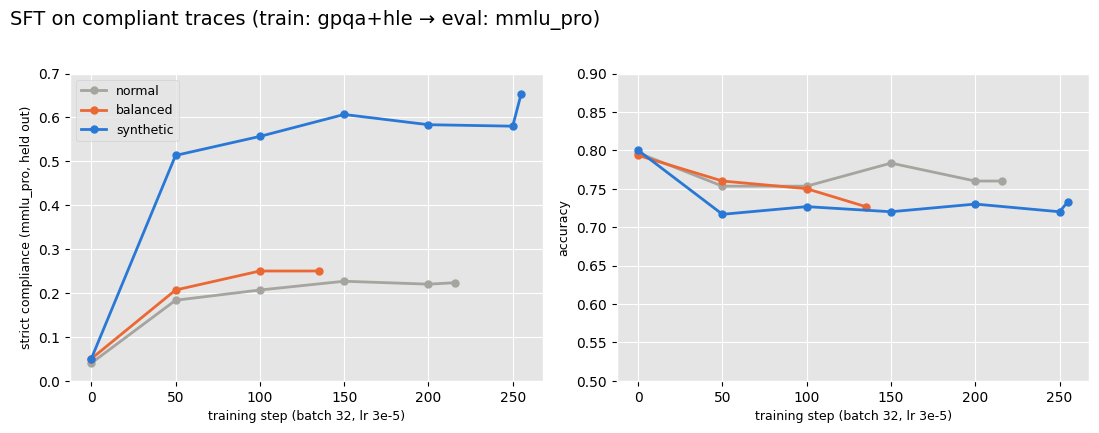

In [ ]:
SFT2_RUNS = {"normal": "gpt_oss_120b_sft2_normal", "balanced": "gpt_oss_120b_sft2_balanced",
             "synthetic": "gpt_oss_120b_sft2_synthetic"}

def load_curve(run):
    summaries = json.load(open(f"tinker_runs/{run}/eval_summary.json"))
    pts = []
    for s in summaries:
        tail = s["path"].rstrip("/").split("/")[-1]
        step = 0 if tail.endswith("epoch_0") else int(tail.split("_step_")[-1])
        pts.append((step, s["compliance_rate"], s["accuracy"]))
    return sorted(pts)

curves = {name: load_curve(run) for name, run in SFT2_RUNS.items()}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
COLORS = {"normal": BASE, "balanced": ORANGE, "synthetic": BLUE}
for name, pts in curves.items():
    steps, comp, acc = zip(*pts)
    ax1.plot(steps, comp, color=COLORS[name], lw=2, marker="o", ms=5, label=name)
    ax2.plot(steps, acc, color=COLORS[name], lw=2, marker="o", ms=5, label=name)
ax1.set_ylabel("strict compliance (mmlu_pro, held out)", fontsize=9)
ax1.set_ylim(0, 0.7)
ax2.set_ylabel("accuracy", fontsize=9)
ax2.set_ylim(0.5, 0.9)
for ax in (ax1, ax2):
    ax.set_xlabel("training step (batch 32, lr 3e-5)", fontsize=9)
ax1.legend(fontsize=9, loc="upper left")
fig.suptitle("SFT on compliant traces (train: gpqa+hle → eval: mmlu_pro)", x=0.005, y=1.02, ha="left")
fig.tight_layout()
fig.savefig("results/plots/sft_leakage_free.png", dpi=150, bbox_inches="tight")
plt.show()

# Mode-transfer matrix

Each column is a model trained on a 3-mode subset (case = upper/lower/alternating; struct = meow/end-of-sentence/repeat; semantic = ignore-question + word-suppression), evaluated on all 9 modes on held-out mmlu_pro. Black-boxed cells were in that run's training set. Key asymmetry: case-training transfers out (ignore_question 0.09→0.62) but nothing transfers into the case modes; word suppression doesn't move even when trained directly.

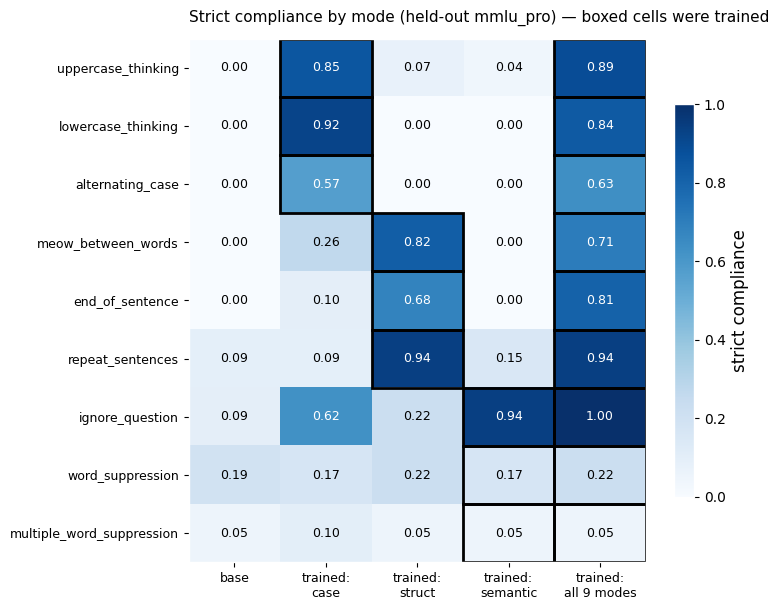

In [ ]:
import numpy as np

FILES = {
    "base": "tinker_runs/gpt_oss_120b_sft2_synthetic/eval/gpt_oss_120b_sft2_synthetic_gpt_oss_120b_sft2_synthetic_epoch_0.json",
    "case": "tinker_runs/gpt_oss_120b_sft3_case/eval/gpt_oss_120b_sft3_case_gpt_oss_120b_sft3_case_step_87.json",
    "struct": "tinker_runs/gpt_oss_120b_sft3_struct/eval/gpt_oss_120b_sft3_struct_gpt_oss_120b_sft3_struct_step_87.json",
    "semantic": "tinker_runs/gpt_oss_120b_sft3_semantic/eval/gpt_oss_120b_sft3_semantic_gpt_oss_120b_sft3_semantic_step_50.json",
    "all 9 modes": "tinker_runs/gpt_oss_120b_sft2_synthetic/eval/gpt_oss_120b_sft2_synthetic_gpt_oss_120b_sft2_synthetic_step_255.json",
}
MODE_ORDER = ["uppercase_thinking", "lowercase_thinking", "alternating_case",
              "meow_between_words", "end_of_sentence", "repeat_sentences",
              "ignore_question", "word_suppression", "multiple_word_suppression"]
TRAINED = {
    "case": {"uppercase_thinking", "lowercase_thinking", "alternating_case"},
    "struct": {"meow_between_words", "end_of_sentence", "repeat_sentences"},
    "semantic": {"ignore_question", "word_suppression", "multiple_word_suppression"},
    "all 9 modes": set(MODE_ORDER),
}

mat = np.zeros((len(MODE_ORDER), len(FILES)))
for j, (name, f) in enumerate(FILES.items()):
    pm = json.load(open(f))["summary"]["per_mode"]
    for i, m in enumerate(MODE_ORDER):
        v = pm.get(m, {"compliant": 0, "n": 1})
        mat[i, j] = v["compliant"] / v["n"]

fig, ax = plt.subplots(figsize=(7.8, 6.2))
im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(FILES)))
ax.set_xticklabels([f"trained:\n{n}" if n not in ("base",) else n for n in FILES], fontsize=9)
ax.set_yticks(range(len(MODE_ORDER)))
ax.set_yticklabels(MODE_ORDER, fontsize=9)
ax.grid(False)
for i, m in enumerate(MODE_ORDER):
    for j, name in enumerate(FILES):
        v = mat[i, j]
        ax.annotate(f"{v:.2f}", (j, i), ha="center", va="center", fontsize=9,
                    color="white" if v > 0.55 else "black")
        if m in TRAINED.get(name, set()):
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="black", lw=2))
ax.set_title("Strict compliance by mode (held-out mmlu_pro) — boxed cells were trained",
             fontsize=11, loc="left", pad=12)
fig.colorbar(im, ax=ax, shrink=0.75, label="strict compliance")
fig.tight_layout()
fig.savefig("results/plots/mode_transfer_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

# Cross-val sweep (synthetic-320): train on 2/3 categories, eval all 9 modes

Five runs on the synthetic-320 datasets (320 examples per mode; every row a unique trace AND a unique question). Three holdout runs use the transformed suppression data (`cv`), two repeat with natural-only suppression traces (`cvnat`: 670/299 genuine traces but only 56/16 unique questions). Left: strict compliance per mode at each run's best checkpoint (black boxes = trained modes). Right: the suppression comparison — keyword-replacement transforms train word suppression (0.14→0.8) while genuine intentional-avoidance traces stay at baseline, and the *identical* genuine ignore_question data works in both variants. So **prompt diversity, not trace authenticity, is what matters** — and the earlier "word suppression is SFT-immune" result was an artifact of 46/17 unique prompts.

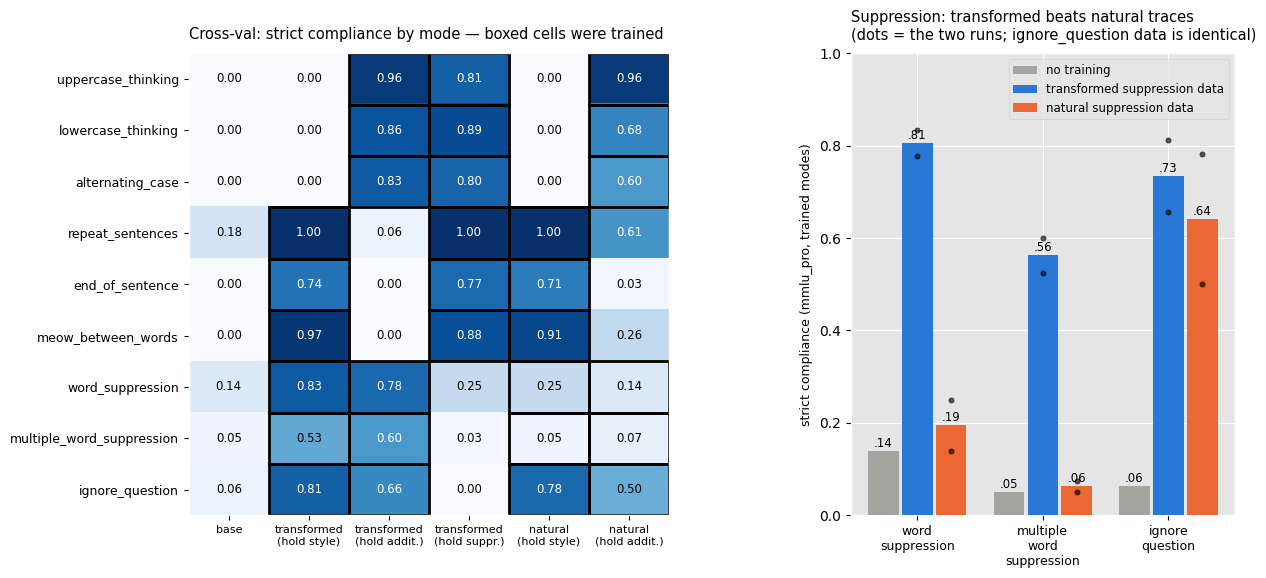

In [ ]:
CV_GROUPS = {
    "style": ["uppercase_thinking", "lowercase_thinking", "alternating_case"],
    "addition": ["repeat_sentences", "end_of_sentence", "meow_between_words"],
    "suppression": ["word_suppression", "multiple_word_suppression", "ignore_question"],
}
CV_MODES = [m for g in ("style", "addition", "suppression") for m in CV_GROUPS[g]]
CV_RUNS = ["cv_holdout_style", "cv_holdout_addition", "cv_holdout_suppression",
           "cvnat_holdout_style", "cvnat_holdout_addition"]

def best_ckpt(run):
    s = json.load(open(f"tinker_runs/gpt_oss_120b_{run}/eval_summary.json"))
    trained = [c for c in s if not c["path"].rstrip("/").endswith("epoch_0")]
    return max(trained, key=lambda c: c["compliance_rate"])

def epoch0(run):
    s = json.load(open(f"tinker_runs/gpt_oss_120b_{run}/eval_summary.json"))
    return next(c for c in s if c["path"].rstrip("/").endswith("epoch_0"))

def pm_rate(ckpt, m):
    v = ckpt["per_mode"][m]
    return v["compliant"] / v["n"]

cols = {"base": epoch0(CV_RUNS[0]), **{r: best_ckpt(r) for r in CV_RUNS}}
mat = np.array([[pm_rate(c, m) for c in cols.values()] for m in CV_MODES])

fig, (ax, ax2) = plt.subplots(1, 2, figsize=(13.5, 6.0),
                              gridspec_kw={"width_ratios": [1.25, 1], "wspace": 0.42})

im = ax.imshow(mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
col_labels = ["base", "transformed\n(hold style)", "transformed\n(hold addit.)",
              "transformed\n(hold suppr.)", "natural\n(hold style)", "natural\n(hold addit.)"]
ax.set_xticks(range(len(cols))); ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(len(CV_MODES))); ax.set_yticklabels(CV_MODES, fontsize=9)
ax.grid(False)
for i, m in enumerate(CV_MODES):
    for j, run in enumerate(cols):
        v = mat[i, j]
        ax.annotate(f"{v:.2f}", (j, i), ha="center", va="center", fontsize=8.5,
                    color="white" if v > 0.55 else "black")
        if run != "base" and m not in CV_GROUPS[run.split("holdout_")[-1]]:
            ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                       edgecolor="black", lw=2))
ax.set_title("Cross-val: strict compliance by mode — boxed cells were trained",
             fontsize=10.5, loc="left", pad=10)

# right panel: transformed vs natural suppression data, averaged over the two
# runs that train suppression (holdout style / holdout addition), dots = runs
SUP = CV_GROUPS["suppression"]
x = np.arange(len(SUP))
w = 0.27
pairs = [(BASE, ["base"], "no training"),
         (BLUE, ["cv_holdout_style", "cv_holdout_addition"], "transformed suppression data"),
         (ORANGE, ["cvnat_holdout_style", "cvnat_holdout_addition"], "natural suppression data")]
for off, (color, runs, label) in zip((-w, 0, w), pairs):
    per_run = np.array([[pm_rate(cols[r], m) for m in SUP] for r in runs])
    mean = per_run.mean(axis=0)
    bars = ax2.bar(x + off, mean, w * 0.9, color=color, label=label, zorder=3)
    for b, v in zip(bars, mean):
        ax2.annotate(f"{v:.2f}".lstrip("0") if v >= 0.005 else "0",
                     (b.get_x() + b.get_width() / 2, v), xytext=(0, 3),
                     textcoords="offset points", ha="center", fontsize=8.5)
    if len(runs) > 1:  # per-run dots
        for row in per_run:
            ax2.scatter(x + off, row, s=14, color="black", zorder=4, alpha=0.65)
ax2.set_xticks(x)
ax2.set_xticklabels([m.replace("_", "\n") for m in SUP], fontsize=9)
ax2.set_ylim(0, 1.0)
ax2.set_ylabel("strict compliance (mmlu_pro, trained modes)", fontsize=9)
ax2.legend(fontsize=8.5, loc="upper right")
ax2.set_title("Suppression: transformed beats natural traces\n(dots = the two runs; ignore_question data is identical)",
              fontsize=10.5, loc="left", pad=10)

fig.savefig("results/plots/crossval_synthetic320.png", dpi=150, bbox_inches="tight")
plt.show()

## Cross-val heatmap, max over checkpoints

Same matrix, but each cell takes the **maximum over all trained checkpoints for that specific mode** (small gray number = the gradient step where the max occurs), rather than one best-overall checkpoint per run. This captures the transient OOD peaks that a single-checkpoint snapshot hides — the per-mode maxima land at different steps (OOD modes peak early, trained modes late), so no single checkpoint attains this matrix.

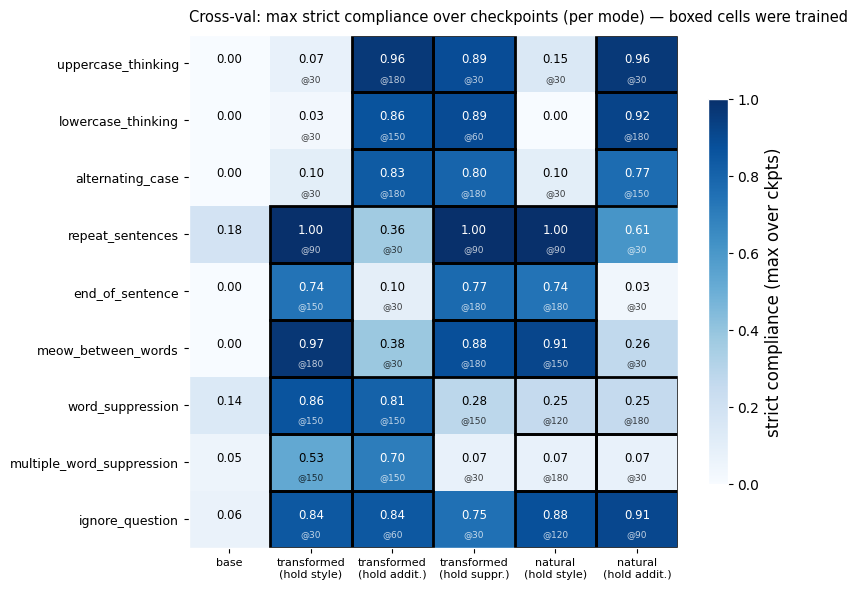

In [ ]:
# cross-val heatmap: per-cell MAX over all trained checkpoints (vs best-overall ckpt above)
def ckpts_with_steps(run):
    s = json.load(open(f"tinker_runs/gpt_oss_120b_{run}/eval_summary.json"))
    out = []
    for c in s:
        tail = c["path"].rstrip("/").split("/")[-1]
        if not tail.endswith("epoch_0"):
            out.append((int(tail.split("_step_")[-1]), c))
    return sorted(out)

base = epoch0(CV_RUNS[0])
max_mat = np.zeros((len(CV_MODES), len(CV_RUNS) + 1))
max_step = np.zeros_like(max_mat, dtype=int)
max_mat[:, 0] = [pm_rate(base, m) for m in CV_MODES]
for j, run in enumerate(CV_RUNS, start=1):
    ckpts = ckpts_with_steps(run)
    for i, m in enumerate(CV_MODES):
        step, ck = max(ckpts, key=lambda sc: pm_rate(sc[1], m))
        max_mat[i, j] = pm_rate(ck, m)
        max_step[i, j] = step

fig, ax = plt.subplots(figsize=(8.2, 6.0))
im = ax.imshow(max_mat, cmap="Blues", vmin=0, vmax=1, aspect="auto")
ax.set_xticks(range(len(CV_RUNS) + 1)); ax.set_xticklabels(col_labels, fontsize=8)
ax.set_yticks(range(len(CV_MODES))); ax.set_yticklabels(CV_MODES, fontsize=9)
ax.grid(False)
for i, m in enumerate(CV_MODES):
    for j, run in enumerate(["base"] + CV_RUNS):
        v = max_mat[i, j]
        fg = "white" if v > 0.55 else "black"
        ax.annotate(f"{v:.2f}", (j, i - 0.09), ha="center", va="center", fontsize=8.5, color=fg)
        if run != "base":
            if v > 0:
                ax.annotate(f"@{max_step[i, j]}", (j, i + 0.26), ha="center", va="center",
                            fontsize=6.5, color=fg, alpha=0.75)
            if m not in CV_GROUPS[run.split("holdout_")[-1]]:
                ax.add_patch(plt.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                           edgecolor="black", lw=2))
ax.set_title("Cross-val: max strict compliance over checkpoints (per mode) — boxed cells were trained",
             fontsize=10.5, loc="left", pad=10)
fig.colorbar(im, ax=ax, shrink=0.75, label="strict compliance (max over ckpts)")
fig.tight_layout()
fig.savefig("results/plots/crossval_synthetic320_max.png", dpi=150, bbox_inches="tight")
plt.show()

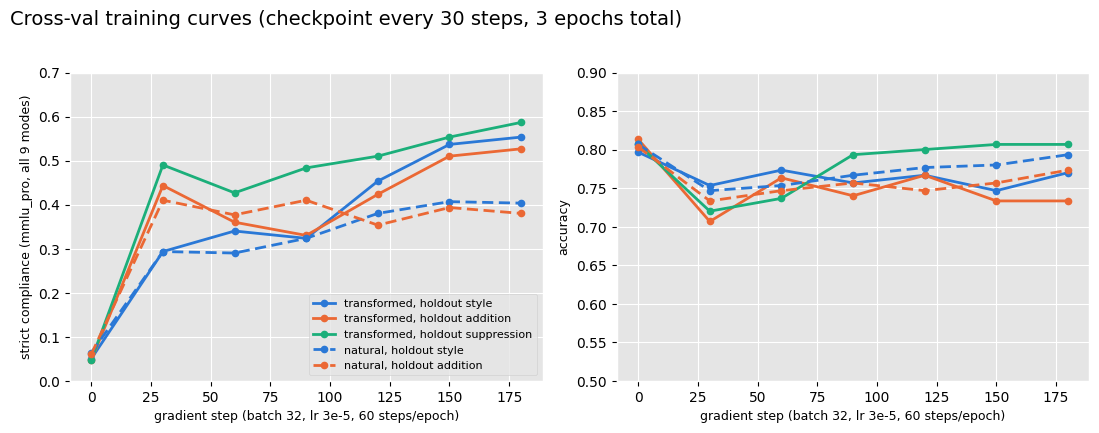

In [ ]:
# training curves: strict compliance / accuracy vs gradient step, all 5 cv runs
CV_COLORS = {"style": BLUE, "addition": ORANGE, "suppression": AQUA}

def cv_curve(run):
    s = json.load(open(f"tinker_runs/gpt_oss_120b_{run}/eval_summary.json"))
    pts = []
    for c in s:
        tail = c["path"].rstrip("/").split("/")[-1]
        step = 0 if tail.endswith("epoch_0") else int(tail.split("_step_")[-1])
        pts.append((step, c["compliance_rate"], c["accuracy"]))
    return sorted(pts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)
for run in CV_RUNS:
    holdout = run.split("holdout_")[-1]
    nat = run.startswith("cvnat")
    steps, comp, acc = zip(*cv_curve(run))
    kw = dict(color=CV_COLORS[holdout], lw=2, marker="o", ms=4.5,
              linestyle=(0, (4, 2)) if nat else "-",
              label=f"{'natural' if nat else 'transformed'}, holdout {holdout}")
    ax1.plot(steps, comp, **kw)
    ax2.plot(steps, acc, **kw)
ax1.set_ylabel("strict compliance (mmlu_pro, all 9 modes)", fontsize=9)
ax1.set_ylim(0, 0.7)
ax2.set_ylabel("accuracy", fontsize=9)
ax2.set_ylim(0.5, 0.9)
for ax in (ax1, ax2):
    ax.set_xlabel("gradient step (batch 32, lr 3e-5, 60 steps/epoch)", fontsize=9)
ax1.legend(fontsize=8, loc="lower right")
fig.suptitle("Cross-val training curves (checkpoint every 30 steps, 3 epochs total)",
             x=0.005, y=1.02, ha="left")
fig.tight_layout()
fig.savefig("results/plots/crossval_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## OOD transfer is transient: it peaks at step 30, then training destroys it

Held-out (OOD) mode compliance over training. Early SFT teaches a general "obey the CoT-format instruction" behavior that lifts *all* modes — most dramatically ignore_question, which reaches **0.75 OOD** after half an epoch of training on style+addition only. Continued training specializes the model onto the six trained formats and the OOD gains collapse, usually to below base. Epoch boundaries (dotted verticals, 60 steps/epoch): the collapse *begins within epoch 1* (ignore_question 0.75→0.38 by step 60, all data still fresh), so it's driven by the amount of specialized training rather than data repetition — though epochs 2–3 finish it off. Implication: for OOD robustness, checkpoint selection dominates — step 30 keeps most in-distribution gains (0.29–0.49 overall) plus all the transfer, while the final checkpoint has none of it.

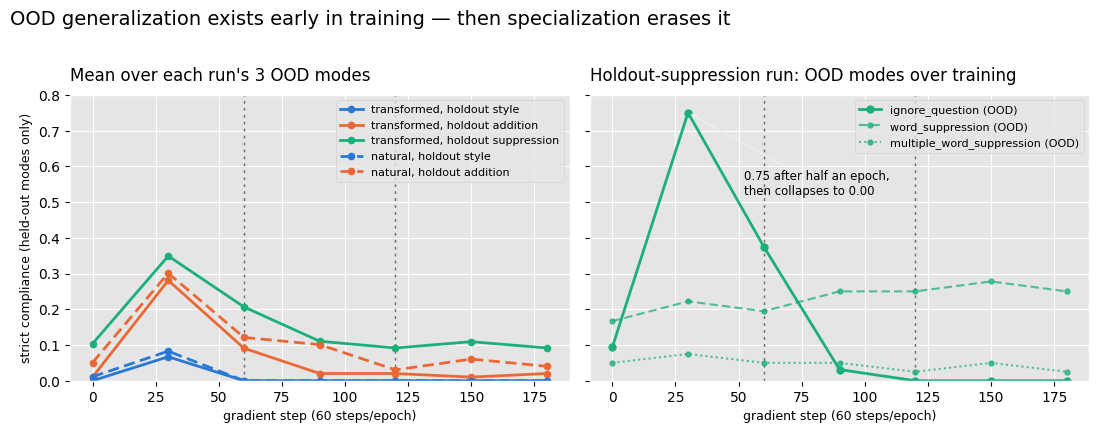

In [ ]:
# OOD (held-out mode) compliance vs gradient step
def mode_curve(run, mode):
    s = json.load(open(f"tinker_runs/gpt_oss_120b_{run}/eval_summary.json"))
    pts = []
    for c in s:
        tail = c["path"].rstrip("/").split("/")[-1]
        step = 0 if tail.endswith("epoch_0") else int(tail.split("_step_")[-1])
        v = c["per_mode"][mode]
        pts.append((step, v["compliant"] / v["n"]))
    return zip(*sorted(pts))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True, sharey=True)

# left: mean OOD compliance per run (its 3 held-out modes)
for run in CV_RUNS:
    holdout = run.split("holdout_")[-1]
    nat = run.startswith("cvnat")
    curves = [mode_curve(run, m) for m in CV_GROUPS[holdout]]
    curves = [(list(s), list(v)) for s, v in curves]
    steps = curves[0][0]
    mean = np.mean([v for _, v in curves], axis=0)
    ax1.plot(steps, mean, color=CV_COLORS[holdout], lw=2, marker="o", ms=4.5,
             linestyle=(0, (4, 2)) if nat else "-",
             label=f"{'natural' if nat else 'transformed'}, holdout {holdout}")
ax1.set_ylabel("strict compliance (held-out modes only)", fontsize=9)
ax1.set_title("Mean over each run's 3 OOD modes", loc="left", pad=10)
ax1.legend(fontsize=8, loc="upper right")

# right: the sharpest case — ignore_question OOD (cv_holdout_suppression)
steps, vals = mode_curve("cv_holdout_suppression", "ignore_question")
ax2.plot(steps, vals, color=AQUA, lw=2, marker="o", ms=5, label="ignore_question (OOD)")
for m, ls in [("word_suppression", (0, (4, 2))), ("multiple_word_suppression", (0, (1, 1.5)))]:
    s_, v_ = mode_curve("cv_holdout_suppression", m)
    ax2.plot(s_, v_, color=AQUA, lw=1.5, marker="o", ms=3.5, linestyle=ls, alpha=0.75,
             label=f"{m} (OOD)")
ax2.annotate("0.75 after half an epoch,\nthen collapses to 0.00", (30, 0.75),
             xytext=(52, 0.52), fontsize=8.5,
             arrowprops=dict(arrowstyle="->", lw=1))
ax2.set_title("Holdout-suppression run: OOD modes over training", loc="left", pad=10)
ax2.legend(fontsize=8, loc="upper right")

for ax in (ax1, ax2):
    ax.set_xlabel("gradient step (60 steps/epoch)", fontsize=9)
    ax.set_ylim(0, 0.8)
    for ep in (60, 120):
        ax.axvline(ep, color="dimgray", lw=1, linestyle=(0, (2, 3)), zorder=1)
fig.suptitle("OOD generalization exists early in training — then specialization erases it",
             x=0.005, y=1.02, ha="left")
fig.tight_layout()
fig.savefig("results/plots/crossval_ood_transient.png", dpi=150, bbox_inches="tight")
plt.show()

## Dense-checkpoint runs (batch 16, 1 epoch, eval every 10 steps)

Same three transformed holdout runs at 6× checkpoint resolution, all within a **single epoch** — every gradient step sees fresh data, so the collapse cannot be a data-repetition effect. OOD peaks arrive at steps 10–40 (~160–640 examples) and decay toward zero on fresh data while in-distribution compliance keeps climbing.

**Caveat found by inspecting rollouts:** the headline ignore_question OOD peak (0.88 at step 30) is inflated by a degenerate behavior — the model rambles off-topic until the 16k-token cap and often never answers (median compliant trace: 75k chars; 16/28 produced no ANSWER). Requiring an extracted answer (dotted black line) gives the honest transient: **0.12 → 0.62 at step 10 → ~0 by step 80**, with all step-10 compliant traces answering normally. The addition-mode OOD peaks are clean as-is (repeat 0.67 / meow 0.41 / end_of_sentence 0.26 — zero no-answer cases, normal ~800-char traces), and no vacuous compliance exists anywhere (no compliant trace under 30 chars). Training data verified: only the thinking part is transformed, outputs untouched.

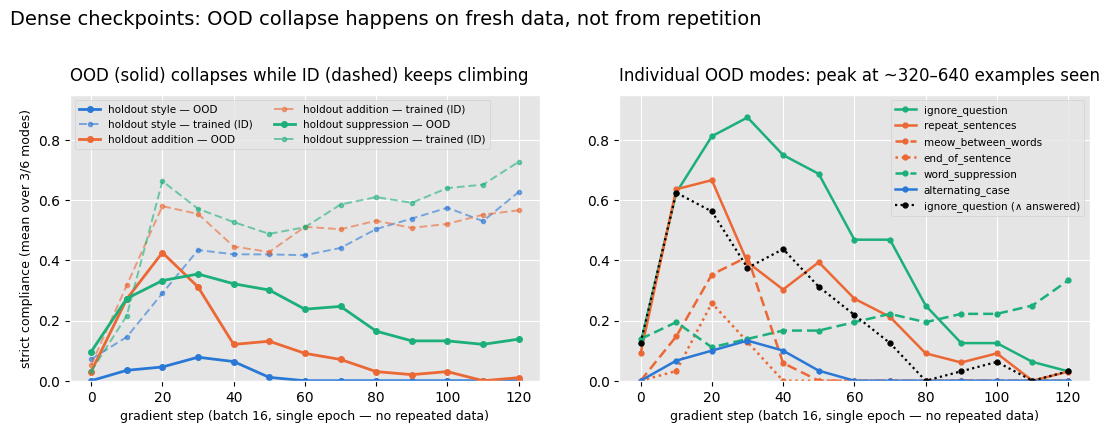

In [ ]:
DENSE_RUNS = [f"cvdense_holdout_{h}" for h in ("style", "addition", "suppression")]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4.2), sharex=True)

# left: mean OOD vs mean ID per run — the divergence is the whole story
for run in DENSE_RUNS:
    holdout = run.split("holdout_")[-1]
    ood_modes = CV_GROUPS[holdout]
    id_modes = [m for m in CV_MODES if m not in ood_modes]
    curves = {m: [list(x) for x in mode_curve(run, m)] for m in CV_MODES}
    steps = curves[ood_modes[0]][0]
    ood = np.mean([curves[m][1] for m in ood_modes], axis=0)
    idm = np.mean([curves[m][1] for m in id_modes], axis=0)
    ax1.plot(steps, ood, color=CV_COLORS[holdout], lw=2, marker="o", ms=4,
             label=f"holdout {holdout} — OOD")
    ax1.plot(steps, idm, color=CV_COLORS[holdout], lw=1.4, marker="o", ms=3,
             linestyle=(0, (4, 2)), alpha=0.6, label=f"holdout {holdout} — trained (ID)")
ax1.set_ylabel("strict compliance (mean over 3/6 modes)", fontsize=9)
ax1.set_title("OOD (solid) collapses while ID (dashed) keeps climbing", loc="left", pad=10)
ax1.legend(fontsize=7.5, loc="upper left", ncol=2)

# right: per-mode OOD trajectories — every transferable mode peaks at step 20-40
OOD_LINES = [("cvdense_holdout_suppression", "ignore_question", AQUA, "-"),
             ("cvdense_holdout_addition", "repeat_sentences", ORANGE, "-"),
             ("cvdense_holdout_addition", "meow_between_words", ORANGE, (0, (4, 2))),
             ("cvdense_holdout_addition", "end_of_sentence", ORANGE, (0, (1, 1.5))),
             ("cvdense_holdout_suppression", "word_suppression", AQUA, (0, (4, 2))),
             ("cvdense_holdout_style", "alternating_case", BLUE, "-")]
for run, m, color, ls in OOD_LINES:
    steps, vals = mode_curve(run, m)
    ax2.plot(steps, vals, color=color, lw=1.8, marker="o", ms=3.5, linestyle=ls, label=m)
# corrected ignore_question: compliant AND actually produced an ANSWER
import glob as _glob
pts = []
for f_ in _glob.glob("tinker_runs/gpt_oss_120b_cvdense_holdout_suppression/eval/*.json"):
    st = 0 if f_.endswith("epoch_0.json") else int(f_.rsplit("_step_", 1)[-1][:-5])
    d_ = json.load(open(f_))["results"]
    ig = [s for r in d_ if r["mode"] == "ignore_question" for s in r["samples"]]
    pts.append((st, sum(1 for s in ig if s["compliance"] == 1 and s.get("extracted_answer")) / len(ig)))
pts.sort()
ax2.plot(*zip(*pts), color="black", lw=1.6, marker="o", ms=3.5, linestyle=(0, (1, 1.5)),
         label="ignore_question (∧ answered)")
ax2.set_title("Individual OOD modes: peak at ~320–640 examples seen", loc="left", pad=10)
ax2.legend(fontsize=7.5, loc="upper right")

for ax in (ax1, ax2):
    ax.set_xlabel("gradient step (batch 16, single epoch — no repeated data)", fontsize=9)
    ax.set_ylim(0, 0.95)
    ax.set_xticks(range(0, 121, 20))
fig.suptitle("Dense checkpoints: OOD collapse happens on fresh data, not from repetition",
             x=0.005, y=1.02, ha="left")
fig.tight_layout()
fig.savefig("results/plots/crossval_dense_ood.png", dpi=150, bbox_inches="tight")
plt.show()

## Does training-mode diversity matter? 1 group × 2 epochs vs 2 groups × 1 epoch

Three new runs (`cvdense_train_{style,addition,suppression}`, 2026-08-19) train on a **single** mode group (3 modes × 320 = 960 examples) for **2 epochs** at batch 16 — the same 120 gradient steps and examples-seen as the dense 2-group runs, isolating training diversity (3 vs 6 modes) at matched compute. Each panel: OOD compliance on one held-out group (mean over its 3 modes), comparing the 2-group trainer against both 1-group trainers.

**Diversity doesn't drive the transfer — the donor group does.** Style-only training transfers onto addition exactly as well as the 6-mode mix (peak 0.43 @20 for both) and onto suppression slightly better (0.37 vs 0.35); honest ignore_question (compliant ∧ answered, dotted black in the right panel) even peaks *higher* from style-only (0.84 @10, all traces answering) than from the 2-group run (0.62 @10). Suppression-only is a weak donor everywhere (peaks ≤0.12), and nothing transfers into style from anything (≤0.12) — the same donor/recipient asymmetry as the sft3 runs. The collapse is also unchanged: the 1-group runs lose all OOD gains by step ~60–90 even though epoch 2 merely repeats data, so the transient is driven by specialization pressure, not by diversity or repetition.

/tmp/ipykernel_2936640/3583472473.py:48: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


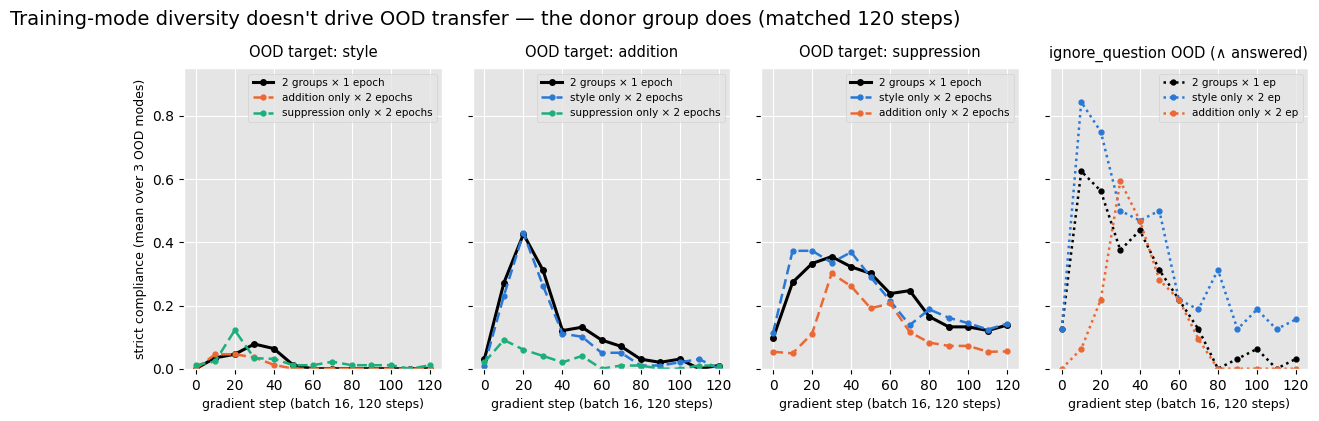

In [ ]:
# 1-group (2 epochs) vs 2-group (1 epoch) trainers at matched 120 steps, batch 16
ONE_GROUP_RUNS = {g: f"cvdense_train_{g}" for g in CV_GROUPS}

fig, axes = plt.subplots(1, 4, figsize=(14.5, 3.9), sharex=True, sharey=True,
                         gridspec_kw={"wspace": 0.12})

for ax, tgt in zip(axes[:3], CV_GROUPS):
    # 2-group trainer: the dense holdout run for this target
    curves = [[list(x) for x in mode_curve(f"cvdense_holdout_{tgt}", m)] for m in CV_GROUPS[tgt]]
    ax.plot(curves[0][0], np.mean([v for _, v in curves], axis=0), color="black", lw=2.2,
            marker="o", ms=4, label="2 groups × 1 epoch")
    # the two 1-group trainers that exclude this target
    for donor in CV_GROUPS:
        if donor == tgt:
            continue
        curves = [[list(x) for x in mode_curve(ONE_GROUP_RUNS[donor], m)] for m in CV_GROUPS[tgt]]
        ax.plot(curves[0][0], np.mean([v for _, v in curves], axis=0), color=CV_COLORS[donor],
                lw=1.8, marker="o", ms=3.5, linestyle=(0, (4, 2)),
                label=f"{donor} only × 2 epochs")
    ax.set_title(f"OOD target: {tgt}", fontsize=10.5, pad=8)
    ax.legend(fontsize=7.5, loc="upper right")
    ax.set_xlabel("gradient step (batch 16, 120 steps)", fontsize=9)
axes[0].set_ylabel("strict compliance (mean over 3 OOD modes)", fontsize=9)

# right panel: honest ignore_question (compliant AND answered) per trainer
ax = axes[3]
import glob as _glob
for run, color, label in [("cvdense_holdout_suppression", "black", "2 groups × 1 ep"),
                          ("cvdense_train_style", CV_COLORS["style"], "style only × 2 ep"),
                          ("cvdense_train_addition", CV_COLORS["addition"], "addition only × 2 ep")]:
    pts = []
    for f_ in _glob.glob(f"tinker_runs/gpt_oss_120b_{run}/eval/*.json"):
        st = 0 if f_.endswith("epoch_0.json") else int(f_.rsplit("_step_", 1)[-1][:-5])
        d_ = json.load(open(f_))["results"]
        ig = [s for r in d_ if r["mode"] == "ignore_question" for s in r["samples"]]
        pts.append((st, sum(1 for s in ig if s["compliance"] == 1 and s.get("extracted_answer")) / len(ig)))
    pts.sort()
    ax.plot(*zip(*pts), color=color, lw=1.8, marker="o", ms=3.5, linestyle=(0, (1, 1.5)), label=label)
ax.set_title("ignore_question OOD (∧ answered)", fontsize=10.5, pad=8)
ax.legend(fontsize=7.5, loc="upper right")
ax.set_xlabel("gradient step (batch 16, 120 steps)", fontsize=9)

for ax in axes:
    ax.set_ylim(0, 0.95)
    ax.set_xticks(range(0, 121, 20))
fig.suptitle("Training-mode diversity doesn't drive OOD transfer — the donor group does (matched 120 steps)",
             x=0.005, y=1.03, ha="left")
fig.tight_layout()
fig.savefig("results/plots/crossval_1grp_vs_2grp.png", dpi=150, bbox_inches="tight")
plt.show()